In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN4/frequency_4_converted.tsv", delimiter="\t", header=None)
df.columns = ['residue', 'ligand', 'frequency']

# Function to extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract and sort residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)
df_sorted = df.sort_values(by='residue_numbers')
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Save the sorted DataFrame to a new TSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN4/sorted_frequency.csv", sep='\t', index=False)


#####calculate the average value when the residue appears in each repeat; otherwise, delete it#######
csv_files = [
    '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN2/sorted_frequency.csv',
    '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN3/sorted_frequency.csv',
    '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/RUN4/sorted_frequency.csv'
]

# Read all CSV files into a list of dataframes and specify the correct separator
dfs = []
for f in csv_files:
    df = pd.read_csv(f, sep='\t')
    dfs.append(df)
    print(f"Columns in {f}: {df.columns.tolist()}")

# Assuming the columns are now correctly named, we can proceed with the rest of the script
common_residues = set(dfs[0]['residue'])
for df in dfs[1:]:
    common_residues.intersection_update(df['residue'])

# Filter dataframes to include only common residues
filtered_dfs = [df[df['residue'].isin(common_residues)] for df in dfs]
merged_df = pd.concat(filtered_dfs).groupby(['residue', 'ligand']).mean().reset_index()

# Save the result
merged_df.to_csv('/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_DHA/average_sorted_frequency.csv', index=False)
print("Averaged contact frequencies saved to 'average_sorted_frequency.csv'.")


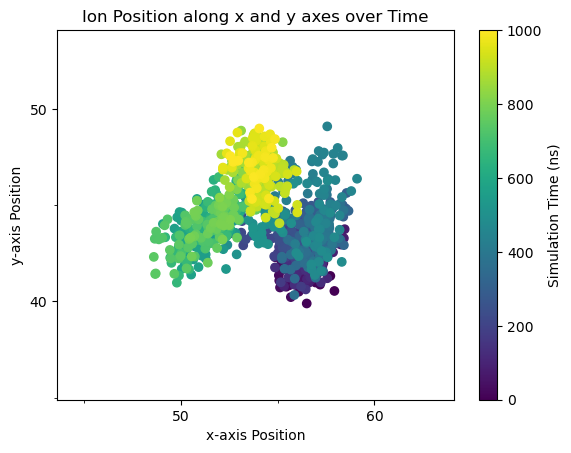

In [ ]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# Load the universe
u = mda.Universe("/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.gro", "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.xtc")

# Select the ion
ca = u.select_atoms('resid 602')

# Initialize lists to store the coordinates and time
x = []
y = []
z = []
time = []

# Iterate over each frame in the trajectory
for ts in u.trajectory:
    x.append(ca.positions[0, 0])  # x-coordinate of the first atom
    y.append(ca.positions[0, 1])  # y-coordinate of the first atom
    z.append(ca.positions[0, 2])  # z-coordinate of the first atom
    time.append(ts.time / 1000.0)  # time of the current frame in ns

# Convert lists to numpy arrays for easier handling
x = np.array(x)
y = np.array(y)
z = np.array(z)
time = np.array(time)

# Create a scatter plot of x and y coordinates, color-coded by simulation time in ns
plt.scatter(x, y, c=time, cmap='viridis')
plt.xlabel('x-axis Position')
plt.ylabel('y-axis Position')
plt.title('Ion Position along x and y axes over Time')
cbar = plt.colorbar(label='Simulation Time (ns)')
cbar.set_label('Simulation Time (ns)')
plt.ylim(min(y-5), max(y+5))
plt.xlim(min(x-5), max(x+5))

# Set up major and minor ticks
plt.gca().xaxis.set_major_locator(MultipleLocator(10))  
plt.gca().xaxis.set_minor_locator(MultipleLocator(5)) 
plt.gca().yaxis.set_major_locator(MultipleLocator(10)) 
plt.gca().yaxis.set_minor_locator(MultipleLocator(5))

# Show the plot
plt.show()


Loading universe...
Universe loaded.
Calculating z-distances...
Z-distances calculated.
Plotting z-distances...


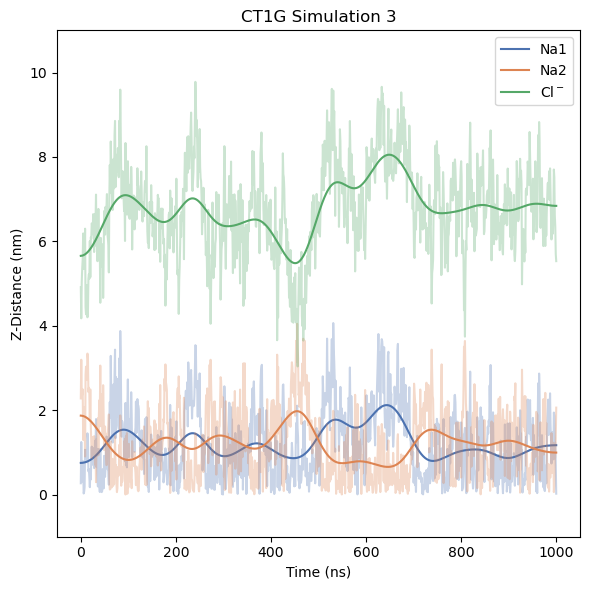

Plot completed.


In [ ]:
#co-factor ions analysis
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

def calculate_z_distance(universe, membrane_sel, ion_indices):
    membrane = universe.select_atoms(membrane_sel)
    ion_z_distances = {ion: [] for ion in ion_indices}
    time = []

    for ts in universe.trajectory:
        com_membrane = membrane.center_of_mass()

        for ion in ion_indices:
            ion_position = universe.atoms[ion].position
            z_distance = np.abs(ion_position[2] - com_membrane[2])
            ion_z_distances[ion].append(z_distance)

        time.append(ts.time/1000)

    time = np.array(time)
    for ion in ion_indices:
        ion_z_distances[ion] = np.array(ion_z_distances[ion])

    return time, ion_z_distances

def plot_z_distances(time, ion_z_distances, ion_indices, smoothing_sigma=30):
    plt.figure(figsize=(6, 6))
    # Define custom labels for ions with charge
    labels = {
        603: r'Na1',  # Sodium ion 2 with positive charge
        602: r'Na2',  # Sodium ion 1 with positive charge
        684: r'Cl$^-$'    # Chloride ion with negative charge
    }
    # Define a color palette
    colors = sns.color_palette("deep", len(ion_indices))  

    for i, ion in enumerate(ion_indices):
        z_distances = ion_z_distances[ion]
        plt.plot(time, z_distances, alpha=0.3, color=colors[i])
        smoothed_z_distances = gaussian_filter1d(z_distances, sigma=smoothing_sigma)
        plt.plot(time, smoothed_z_distances, label=f'{labels.get(ion, "Ion")}', color=colors[i])

    plt.xlim([-50, 1050]) 
    plt.ylim([-1, 11]) 
    plt.xticks(ticks=[0, 200, 400, 600, 800, 1000])
    plt.yticks(ticks=[0, 2, 4, 6, 8, 10]) 
    ax = plt.gca()
    plt.xlabel('Time (ns)')
    plt.ylabel('Z-Distance (nm)')
    plt.title('CT1G Simulation 3')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.savefig('/Users/chenyifang/Desktop/RA/GAA/md/R3_ions_z.png', dpi=600, bbox_inches='tight')
    plt.show()

#loading and processing
top_file = "/Users/chenyifang/Desktop/RA/GAA/md/R3/md_center.gro"
traj_file = "/Users/chenyifang/Desktop/RA/GAA/md/R3/md_center.xtc"
membrane_sel = 'resid 57:600'
ion_indices = [603, 602, 684]

# Load the universe
print("Loading universe...")
u = mda.Universe(top_file, traj_file)
print("Universe loaded.")

# Calculate z-distances
print("Calculating z-distances...")
time, ion_z_distances = calculate_z_distance(u, membrane_sel, ion_indices)
print("Z-distances calculated.")

# Plot z-distances
print("Plotting z-distances...")
plot_z_distances(time, ion_z_distances, ion_indices, smoothing_sigma=30)
print("Plot completed.")


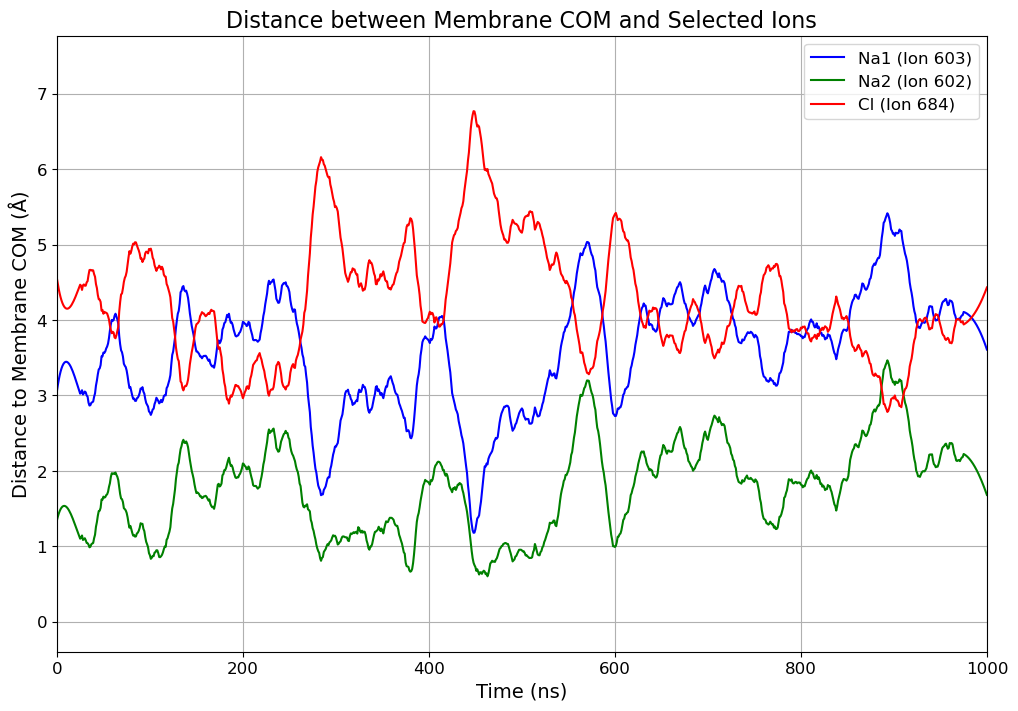

In [ ]:
#ions and CoM distance of membrane (distance vs time)
import MDAnalysis as mda
from MDAnalysis.analysis import align
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Load the trajectory and topology files
u = mda.Universe("/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.gro", "/Users/chenyifang/Desktop/RA/SLC6A8/R1/md_center.xtc")

# Select the membrane and the specific ions
membrane = u.select_atoms("resname POPC")
ion1 = u.select_atoms("index 602")
ion2 = u.select_atoms("index 603")
ion3 = u.select_atoms("index 684")

# Prepare to store distances
distances_ion1 = []
distances_ion2 = []
distances_ion3 = []
times = []

# Iterate over trajectory frames
for ts in u.trajectory:
    com_membrane = membrane.center_of_mass()
    com_membrane_z = com_membrane[2]
    
    ion1_z = ion1.positions[0][2]
    ion2_z = ion2.positions[0][2]
    ion3_z = ion3.positions[0][2]
    
    distances_ion1.append(np.abs(com_membrane_z - ion1_z))
    distances_ion2.append(np.abs(com_membrane_z - ion2_z))
    distances_ion3.append(np.abs(com_membrane_z - ion3_z))
    
    # Store the time in nanoseconds
    times.append(ts.time / 1000)  # assuming time is in ps, convert to ns

# Apply Savitzky-Golay filter to smooth the data
window_length = 51  # Window length must be odd
polyorder = 3      # Polynomial order
distances_ion1_smooth = savgol_filter(distances_ion1, window_length, polyorder)
distances_ion2_smooth = savgol_filter(distances_ion2, window_length, polyorder)
distances_ion3_smooth = savgol_filter(distances_ion3, window_length, polyorder)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(times, distances_ion1_smooth, label='Na1 (Ion 603)', color='blue')
plt.plot(times, distances_ion2_smooth, label='Na2 (Ion 602)', color='green')
plt.plot(times, distances_ion3_smooth, label='Cl (Ion 684)', color='red')

# Customizing the plot for publication quality
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('Distance to Membrane COM (Å)', fontsize=14)
plt.title('Distance between Membrane COM and Selected Ions', fontsize=16)
plt.legend(fontsize=12)
plt.xlim([0, max(times)])
plt.ylim([min(min(distances_ion1_smooth), min(distances_ion2_smooth), min(distances_ion3_smooth)) - 1,
          max(max(distances_ion1_smooth), max(distances_ion2_smooth), max(distances_ion3_smooth)) + 1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


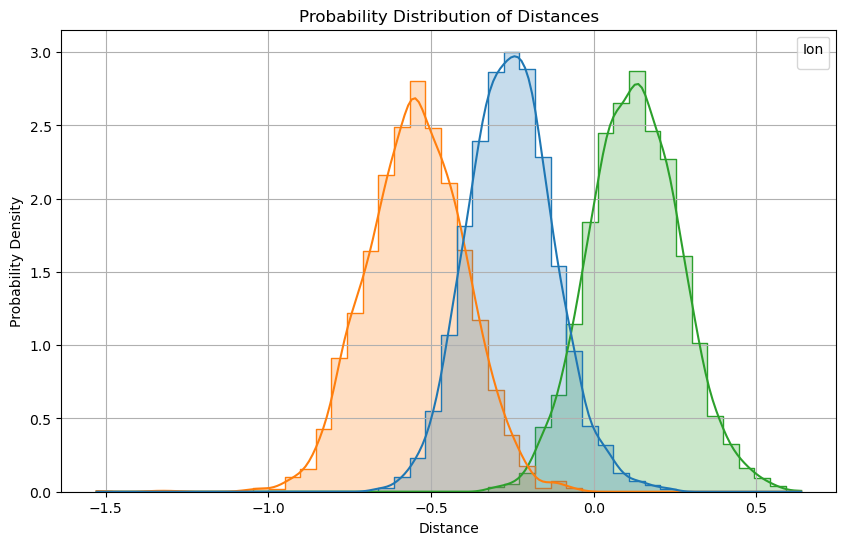

In [ ]:
#ions and CoM distance of membrane (histogram distribution)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('/Users/chenyifang/Desktop/CT1C.csv')
melted_data = data.melt(var_name='Ion', value_name='Distance')

plt.figure(figsize=(10, 6))
sns.histplot(melted_data, x='Distance', hue='Ion', stat='density', common_norm=False, element='step', kde=True)
plt.xlabel('Distance')
plt.ylabel('Probability Density')
plt.title('Probability Distribution of Distances')
plt.legend(title='Ion')
plt.grid(True)
plt.show()

# Normalize the distances
normalized_data = melted_data.groupby('Ion').apply(lambda x: x['Distance'] / x['Distance'].max()).reset_index(name='Normalized_Distance')
normalized_data.to_csv('/Users/chenyifang/Desktop/CT1C_normalized_distances.csv', index=False)


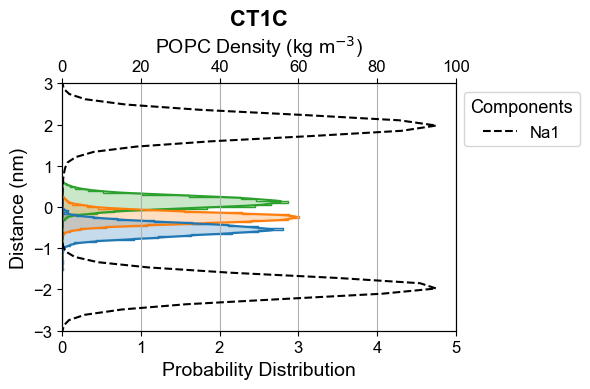

In [ ]:
#ions and CoM distance of membrane (histogram distribution with changed axis)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the distance data
distance_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/CT1C.csv')
melted_distance_data = distance_data.melt(var_name='Ion', value_name='Distance')
popc_density_data = pd.read_csv('/Users/chenyifang/Desktop/new_figure/POPC_CT1C.csv')

# Plotting
fig, ax1 = plt.subplots(figsize=(6, 4))
sns.histplot(melted_distance_data, y='Distance', hue='Ion', stat='density', common_norm=False, element='step', kde=True, ax=ax1)
ax1.set_ylabel('Distance (nm)', fontsize=14)
ax1.set_xlabel('Probability Distribution', fontsize=14)
ax1.set_ylim([-3, 3])  # Adjust y limits as needed
ax1.set_xlim([0, 5])  # Adjust x limits as needed
ax1.tick_params(axis='both', which='major', labelsize=12)

ax2 = ax1.twiny()
popc_line, = ax2.plot(popc_density_data['POPC'], popc_density_data['Distance'], color='black', linestyle='--', label='--POPC')
ax2.set_xlabel('POPC Density (kg m$^{-3}$)', fontsize=14)
ax2.set_xlim([0, 100])  # Adjust secondary x limits as needed
ax2.tick_params(axis='x', which='major', labelsize=12)
ion_handles, ion_labels = ax1.get_legend_handles_labels()
ion_labels = ['Na1', 'Na2', 'Cl$^-$', 'POPC']
handles = ion_handles + [popc_line]
labels = ion_labels + ['--POPC']

ax1.legend(handles, labels, title='Components', title_fontsize='13', fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))
plt.title('CT1C', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/new_figure/CT1C_ion_stability.png', dpi=600, bbox_inches='tight')
plt.grid(True)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.show()
